<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/Customer_Churn(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import chi2_contingency, f_oneway
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

In [ ]:
churn_1 = pd.read_csv("Dataset/Bank Customer Churn Prediction.csv")
churn_1

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
churn_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
for column in churn_1.columns:
    print(column, "\n")
    print(set(churn_1[column]))
    print("\n")

customer_id 

{15695872, 15794178, 15794187, 15630349, 15597591, 15630363, 15794204, 15728669, 15663134, 15597602, 15597610, 15728683, 15761453, 15728693, 15663161, 15663164, 15695932, 15794236, 15663168, 15630402, 15728706, 15761477, 15728709, 15794253, 15630413, 15761487, 15794257, 15630419, 15761497, 15794266, 15663194, 15794273, 15761506, 15794276, 15794278, 15761525, 15794297, 15663234, 15630466, 15728773, 15597709, 15663249, 15761554, 15794323, 15663252, 15663263, 15794345, 15597739, 15630511, 15696047, 15794356, 15696054, 15728823, 15794360, 15696061, 15663294, 15728829, 15761600, 15728838, 15761606, 15663312, 15630551, 15794396, 15696098, 15794413, 15794414, 15630580, 15728885, 15761654, 15696120, 15630592, 15761670, 15728906, 15696141, 15728912, 15728917, 15630617, 15663386, 15761692, 15794468, 15794472, 15761706, 15794479, 15696175, 15761713, 15663410, 15630641, 15761717, 15761720, 15794493, 15663421, 15597885, 15728963, 15630661, 15761733, 15597896, 15597901, 15663438, 15663

churn
0    7963
1    2037
Name: count, dtype: int64


C:\Users\Dev\AppData\Local\Temp\ipykernel_2504\2898526146.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(churn_1['churn']))


<Axes: xlabel='churn', ylabel='count'>

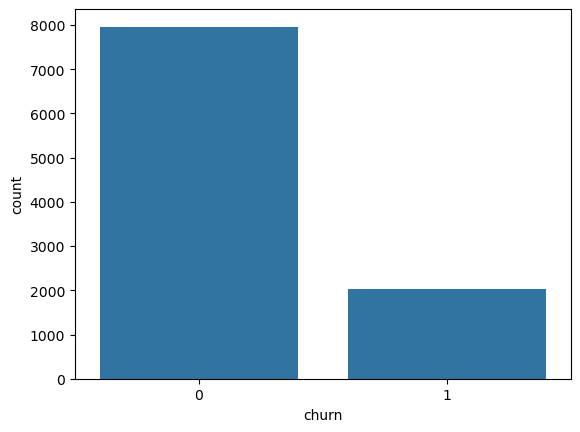

In [ ]:
print(pd.value_counts(churn_1['churn']))
sns.countplot(x = 'churn', data=churn_1)


In [ ]:
2037/7963

0.25580811252040686

C:\Users\Dev\AppData\Local\Temp\ipykernel_2504\3211797635.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(churn_1['credit_score'])


<Axes: xlabel='credit_score', ylabel='Density'>

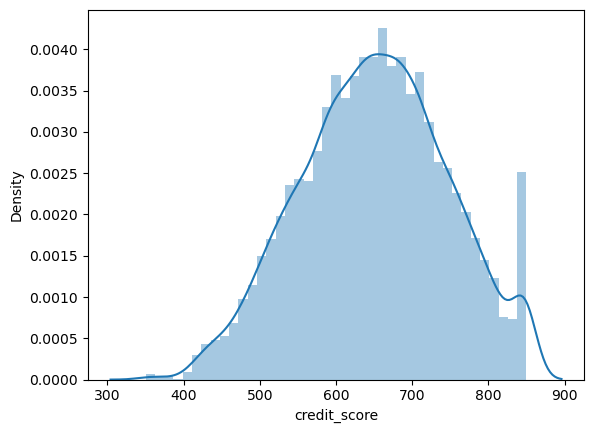

In [ ]:
sns.distplot(churn_1['credit_score'])

C:\Users\Dev\AppData\Local\Temp\ipykernel_2504\3782140588.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(churn_1['age'])


<Axes: xlabel='age', ylabel='Density'>

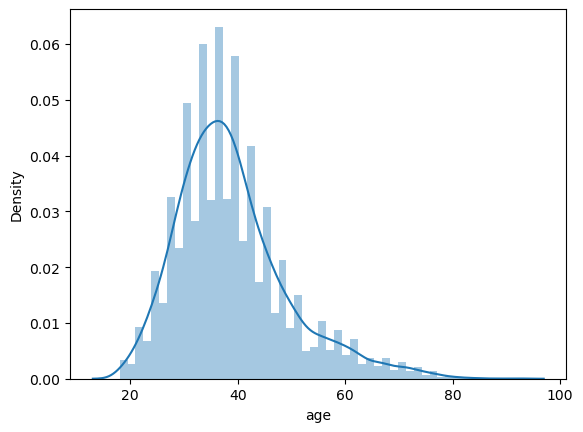

In [ ]:
sns.distplot(churn_1['age'])

C:\Users\Dev\AppData\Local\Temp\ipykernel_2504\2734039533.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(churn_1['balance'])


<Axes: xlabel='balance', ylabel='Density'>

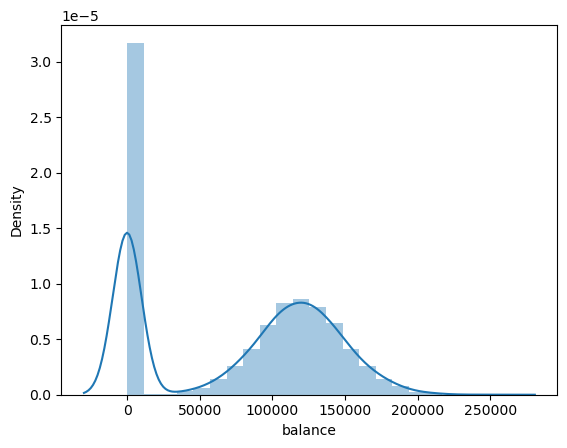

In [ ]:
sns.distplot(churn_1['balance'])

C:\Users\Dev\AppData\Local\Temp\ipykernel_2504\1962488636.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(churn_1['estimated_salary'])


<Axes: xlabel='estimated_salary', ylabel='Density'>

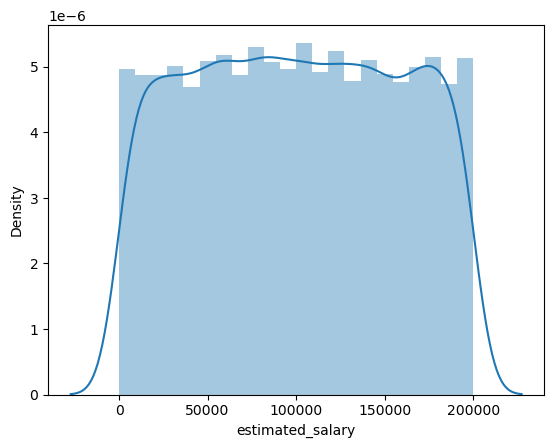

In [ ]:
sns.distplot(churn_1['estimated_salary'])

In [ ]:
churn_2 = churn_1.drop(columns=["customer_id"])

<Axes: >

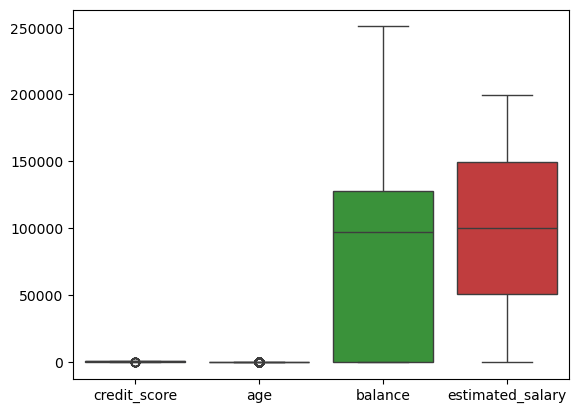

In [ ]:
continuous_features = churn_2[["credit_score", "age", "balance", "estimated_salary"]]
sns.boxplot(continuous_features)

<Axes: ylabel='credit_score'>

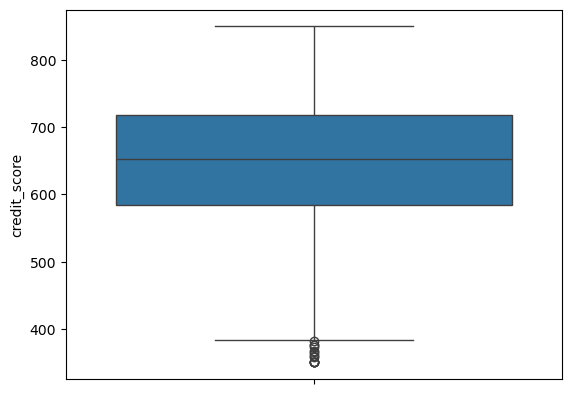

In [ ]:
sns.boxplot(continuous_features['credit_score'])

<Axes: ylabel='age'>

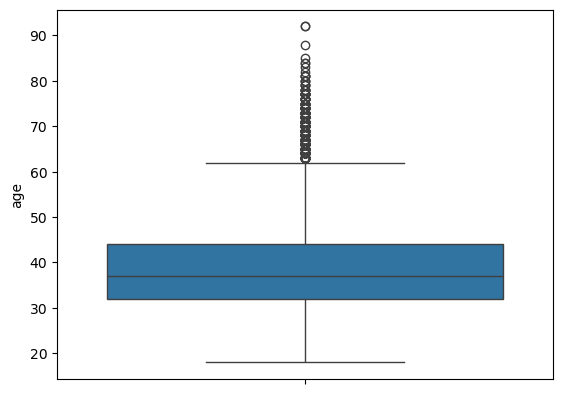

In [ ]:
sns.boxplot(continuous_features['age'])

<Axes: ylabel='balance'>

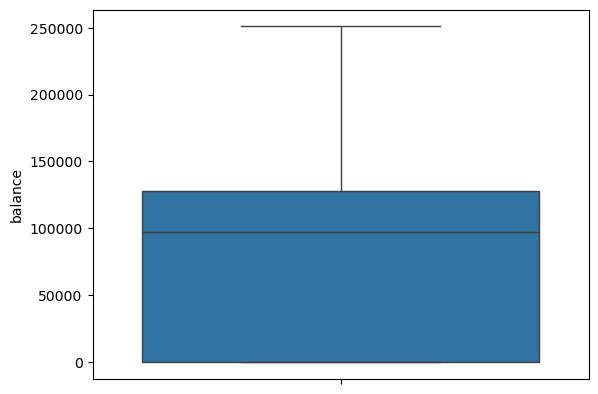

In [ ]:
sns.boxplot(continuous_features['balance'])

<Axes: ylabel='estimated_salary'>

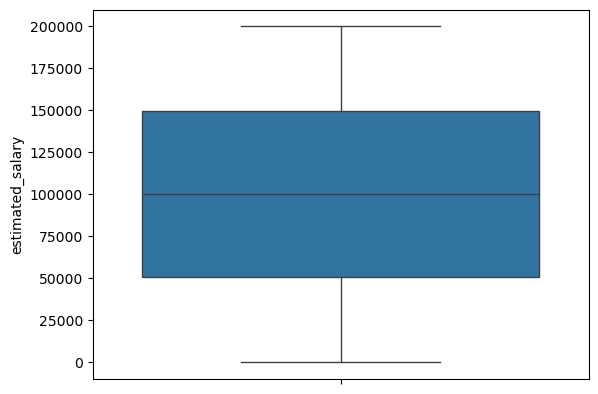

In [ ]:
sns.boxplot(continuous_features['estimated_salary'])

In [ ]:
def outlier_removal(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3-q1
    lower_fence = q1 - 1.5*iqr
    upper_fence = q3 + 1.5*iqr
    trimmed_data = df[(df[column] > lower_fence) & (df[column] < upper_fence)]
    return trimmed_data

churn_3 = outlier_removal(df = churn_2, column = "age")
churn_4 = outlier_removal(df = churn_3, column = "credit_score")

<Axes: ylabel='age'>

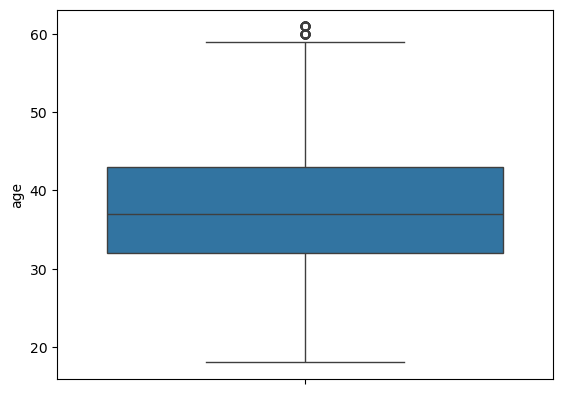

In [ ]:
sns.boxplot(churn_4['age'])

<Axes: ylabel='credit_score'>

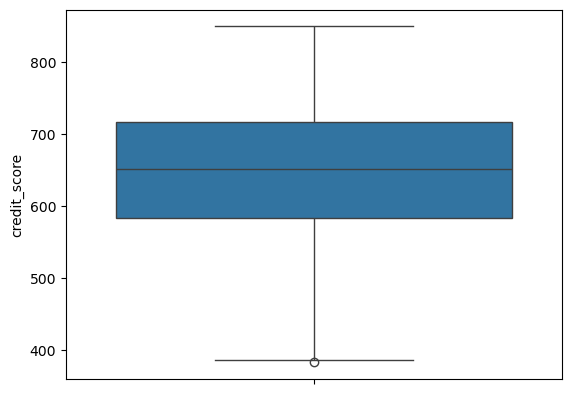

In [ ]:
sns.boxplot(churn_4['credit_score'])

<Axes: ylabel='balance'>

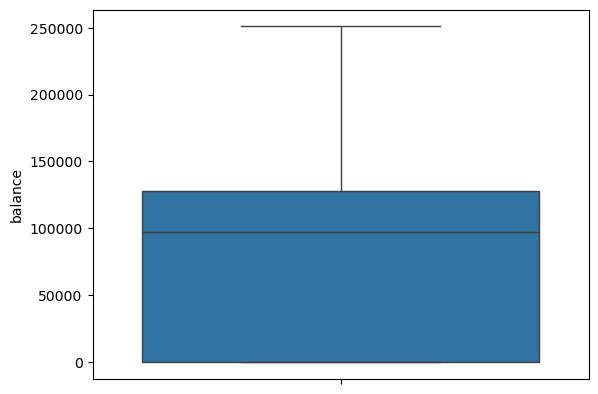

In [ ]:
sns.boxplot(churn_4['balance'])

<Axes: ylabel='estimated_salary'>

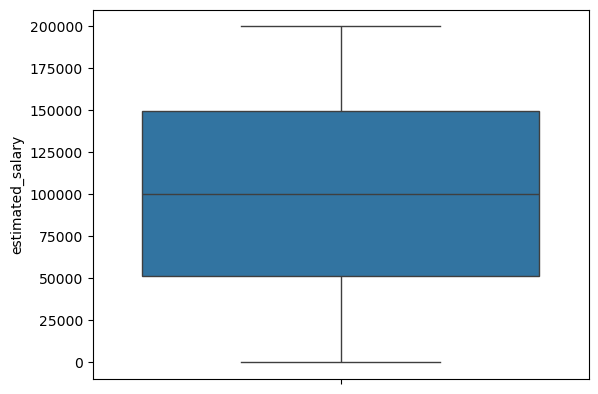

In [ ]:
sns.boxplot(churn_4['estimated_salary'])

In [ ]:
churn_4

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
x = churn_4.drop(columns=['churn'])
y = churn_4['churn']

In [ ]:
x_continuous = x[["credit_score", "age", "balance", "estimated_salary"]]
scale = MinMaxScaler()

x_normalized = scale.fit_transform(x_continuous)

In [ ]:
x_continuous_normalized = pd.DataFrame(data = x_normalized, columns=["credit_score", "age", "balance", "estimated_salary"])
x_continuous_normalized

,credit_score,age,balance,estimated_salary
0,0.505353,0.558140,0.000000,0.506735
1,0.481799,0.534884,0.334031,0.562709
2,0.254818,0.558140,0.636357,0.569654
3,0.676660,0.488372,0.000000,0.469120
4,1.000000,0.581395,0.500246,0.395400
...,...,...,...,...
9569,0.830835,0.488372,0.000000,0.481341
9570,0.284797,0.395349,0.228657,0.508490
9571,0.698073,0.418605,0.000000,0.210390
9572,0.832976,0.558140,0.299226,0.464429


In [ ]:
churn_5 = pd.get_dummies(churn_4, columns = ['country', 'gender'], dtype=int)
churn_6 = churn_5.drop(columns = ['credit_score', 'age', 'balance', 'estimated_salary'])
churn_6

,tenure,products_number,credit_card,active_member,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,2,1,1,1,1,1,0,0,1,0
1,1,1,0,1,0,0,0,1,1,0
2,8,3,1,0,1,1,0,0,1,0
3,1,2,0,0,0,1,0,0,1,0
4,2,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
9995,5,2,1,0,0,1,0,0,0,1
9996,10,1,1,1,0,1,0,0,0,1
9997,7,1,0,1,1,1,0,0,1,0
9998,3,2,1,0,1,0,1,0,0,1


In [ ]:
x_new = pd.concat([x_continuous_normalized.reset_index(drop=True), churn_6.reset_index(drop=True)], axis=1)

In [ ]:
x_new = x_new.drop(columns=['churn'])
x_new

,credit_score,age,balance,estimated_salary,tenure,products_number,credit_card,active_member,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,0.505353,0.558140,0.000000,0.506735,2,1,1,1,1,0,0,1,0
1,0.481799,0.534884,0.334031,0.562709,1,1,0,1,0,0,1,1,0
2,0.254818,0.558140,0.636357,0.569654,8,3,1,0,1,0,0,1,0
3,0.676660,0.488372,0.000000,0.469120,1,2,0,0,1,0,0,1,0
4,1.000000,0.581395,0.500246,0.395400,2,1,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9569,0.830835,0.488372,0.000000,0.481341,5,2,1,0,1,0,0,0,1
9570,0.284797,0.395349,0.228657,0.508490,10,1,1,1,1,0,0,0,1
9571,0.698073,0.418605,0.000000,0.210390,7,1,0,1,1,0,0,1,0
9572,0.832976,0.558140,0.299226,0.464429,3,2,1,0,0,1,0,0,1


In [ ]:
churn_1

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x_new, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = LogisticRegression()
model.fit(xtrain, ytrain)

LogisticRegression()

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
ytest_predictions[0]

0

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.8267397832615224
testing accuracy :  0.8203655352480418


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1466,   63],
       [ 281,  105]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89      1529
           1       0.62      0.27      0.38       386

    accuracy                           0.82      1915
   macro avg       0.73      0.62      0.64      1915
weighted avg       0.80      0.82      0.79      1915



In [ ]:
model = LogisticRegression(C=0.9, dual= False, max_iter= 500, penalty= 'elasticnet', solver= 'saga', l1_ratio=0.2)
model.fit(xtrain, ytrain)

LogisticRegression(C=0.9, l1_ratio=0.2, max_iter=500, penalty='elasticnet',
                   solver='saga')

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.8268703486094791
testing accuracy :  0.8198433420365535


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1465,   64],
       [ 281,  105]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89      1529
           1       0.62      0.27      0.38       386

    accuracy                           0.82      1915
   macro avg       0.73      0.62      0.64      1915
weighted avg       0.80      0.82      0.79      1915



In [ ]:
# Grid Search CV

param_grid = {
    'penalty' : ['elasticnet', 'l1', 'l2', None],
    'C' : [0.7, 0.5],
    'dual': [True, False],
    'max_iter': [100, 200, 500, 1000],
    'solver':['liblinear', 'newton-cholesky', "newton-cg"]
}
logistic_regression = LogisticRegression()
gscv = GridSearchCV(estimator=logistic_regression, cv=5, param_grid = param_grid, verbose = 3)
gscv.fit(xtrain, ytrain)
print(gscv.best_params_)
print(gscv.best_score_)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV 1/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 1/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, dual=True, max_iter=100, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 4/5] END C=

C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV 3/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=liblinear;, score=0.822 total time=   0.0s
[CV 4/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=liblinear;, score=0.818 total time=   0.0s
[CV 5/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=liblinear;, score=0.822 total time=   0.0s
[CV 1/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 1/5] END C=0.7, dual=True, max_iter=100, penalty=l2, solver=newton-cg;, score=nan total time=   0.0s
[CV 2/5] END C=0.7,

C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV 4/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 1/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 1/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, solver=newton-cg;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, dual=True, max_iter=200, penalty=elasticnet, s

...

[CV 5/5] END C=0.5, dual=False, max_iter=500, penalty=None, solver=newton-cg;, score=0.822 total time=   0.0s
[CV 1/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 2/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 3/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 4/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 5/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 1/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 2/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 3/5] END C=0.5, dual=False, max_iter=1000, penalty=elasticnet, solver

C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\_newton_solver.py:497: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration #2. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Ill-conditioned matrix (rcond=3.51879e-18): result may not be accurate.
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_glm\_newt

[CV 1/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cholesky;, score=0.837 total time=   0.0s
[CV 2/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cholesky;, score=0.834 total time=   0.0s
[CV 3/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cholesky;, score=0.817 total time=   0.0s
[CV 4/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cholesky;, score=0.819 total time=   0.0s
[CV 5/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cholesky;, score=0.822 total time=   0.0s
[CV 1/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cg;, score=0.837 total time=   0.0s


C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Dev\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
680 fits failed out of a total of 960.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_

[CV 2/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cg;, score=0.834 total time=   0.0s
[CV 3/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cg;, score=0.817 total time=   0.0s
[CV 4/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cg;, score=0.819 total time=   0.0s
[CV 5/5] END C=0.5, dual=False, max_iter=1000, penalty=None, solver=newton-cg;, score=0.822 total time=   0.0s
{'C': 0.7, 'dual': False, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
0.8275224984779314


In [ ]:
# Feature Selection
# 1. Filter Methods
# 2. Wrapper Methods
# 3. Embedded Methods

# 1. Filter Methods
# a. Chi-Square Test
# b. ANOVA

# 2. Wrapper Methods
# a. Forward Feature Selection
# b. Backward Feature ELimination

In [ ]:
# A Dataset consist of two parts
# 1. Features (Continuous, Categorical)
# 2. Label (Continuous, Categorical)

# Case 1 : Feature -> Continuous, Label -> Continuous -> Correlation
# Case 2 : Feature -> Categorical, Label -> Categorical -> Chi-Square Test
# Case 3 : Feature -> Categorical, Label -> Continuous -> ANOVA
# Case 4: Feature -> Continuous, Label -> Categorical -> ANOVA


In [ ]:
# Chi-Square Test

dataset = pd.concat([x_new.reset_index(drop=True),y.reset_index(drop=True)], axis=1)
dataset.columns

Index(['credit_score', 'age', 'balance', 'estimated_salary', 'tenure',
       'products_number', 'credit_card', 'active_member', 'country_France',
       'country_Germany', 'country_Spain', 'gender_Female', 'gender_Male',
       'churn'],
      dtype='object')

In [ ]:
def chi2_test(column, churn):
    contingency_table = pd.crosstab(column, churn)
    print(contingency_table)
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    #print("Chi-Square statistic:", chi2_stat)
    #print("p-value:", p_value)
    #print("Degrees of Freedom:", dof)
    #print("Expected frequencies:\n", expected)

    # Interpretation
    alpha = 0.05  # significance level
    if p_value < alpha:
        print("Reject the null hypothesis. There is a significant association between the two variables." )
    else:
        print("Fail to reject the null hypothesis. There is no significant association between the two variables.")


categorical_features = ['tenure','products_number', 'credit_card', 'active_member', 'country_France', 'country_Germany',
                        'country_Spain', 'gender_Female','gender_Male']
for column in categorical_features:
    print(column, "churn")
    chi2_test(dataset[column], dataset["churn"])

tenure churn
churn     0    1
tenure          
0       302   90
1       770  216
2       813  194
3       764  198
4       759  193
5       768  198
6       739  186
7       824  168
8       806  187
9       733  201
10      368   97
Fail to reject the null hypothesis. There is no significant association between the two variables.
products_number churn
churn               0     1
products_number            
1                3517  1338
2                4087   326
3                  42   206
4                   0    58
Reject the null hypothesis. There is a significant association between the two variables.
credit_card churn
churn           0     1
credit_card            
0            2238   581
1            5408  1347
Fail to reject the null hypothesis. There is no significant association between the two variables.
active_member churn
churn             0     1
active_member            
0              3532  1231
1              4114   697
Reject the null hypothesis. There is a significant

In [ ]:
dataset1 = dataset.drop(columns= ['tenure', 'credit_card'])
x1 = dataset1.drop(columns=['churn'])
y1 = dataset1['churn']

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x1, y1, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = LogisticRegression()
model.fit(xtrain, ytrain)

LogisticRegression()

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.8277843060451756
testing accuracy :  0.8187989556135771


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1466,   63],
       [ 284,  102]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89      1529
           1       0.62      0.26      0.37       386

    accuracy                           0.82      1915
   macro avg       0.73      0.61      0.63      1915
weighted avg       0.79      0.82      0.79      1915



In [ ]:
# Anova

def anova(column, churn):
    f_statistic, p_value = f_oneway(column, churn)

    #print("F-statistic:", f_statistic)
    #print("P-value:", p_value)

    # Interpret the result
    alpha = 0.05  # Common significance level (5%)

    if p_value < alpha:
        print("Reject Null Hypothesis. There is a statistically significant difference among the groups.")
    else:
        print("Failed to reject null hypothesis. There is no statistically significant difference among the groups.")


continuous_features = ["credit_score",  "age", "balance",  "estimated_salary"]
for column in continuous_features:
    print(column, "churn")
    anova(dataset[column], dataset["churn"])

credit_score churn
There is a statistically significant difference among the groups.
age churn
There is a statistically significant difference among the groups.
balance churn
There is a statistically significant difference among the groups.
estimated_salary churn
There is a statistically significant difference among the groups.


In [ ]:
dataset

,credit_score,age,balance,estimated_salary,tenure,products_number,credit_card,active_member,country_France,country_Germany,country_Spain,gender_Female,gender_Male,churn
0,0.505353,0.558140,0.000000,0.506735,2,1,1,1,1,0,0,1,0,1
1,0.481799,0.534884,0.334031,0.562709,1,1,0,1,0,0,1,1,0,0
2,0.254818,0.558140,0.636357,0.569654,8,3,1,0,1,0,0,1,0,1
3,0.676660,0.488372,0.000000,0.469120,1,2,0,0,1,0,0,1,0,0
4,1.000000,0.581395,0.500246,0.395400,2,1,1,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9569,0.830835,0.488372,0.000000,0.481341,5,2,1,0,1,0,0,0,1,0
9570,0.284797,0.395349,0.228657,0.508490,10,1,1,1,1,0,0,0,1,0
9571,0.698073,0.418605,0.000000,0.210390,7,1,0,1,1,0,0,1,0,1
9572,0.832976,0.558140,0.299226,0.464429,3,2,1,0,0,1,0,0,1,1


In [ ]:
x2 = dataset.drop(columns=["churn"])
y2 = dataset["churn"]
xtrain, xtest, ytrain, ytest = train_test_split(x2, y2, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Forward Feature Selection
logistic_regression = LogisticRegression()
sfs1 = sfs(estimator=logistic_regression, k_features=7, cv=10, verbose=2, forward = True)
sfs1 = sfs1.fit(xtrain, ytrain)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:    0.6s finished

[2024-08-09 22:33:59] Features: 1/7 -- score: 0.8050661274083177[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:    0.7s finished

[2024-08-09 22:34:00] Features: 2/7 -- score: 0.8187743818153894[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.6s finished

[2024-08-09 22:34:01] Features: 3/7 -- score: 0.8266074506390895[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 

In [ ]:
feature_names = list(sfs1.k_feature_names_)
print(feature_names)

['age', 'estimated_salary', 'tenure', 'products_number', 'active_member', 'country_Germany', 'gender_Female']


In [ ]:
x3 = x2[["age", "estimated_salary", "tenure", "products_number", "active_member", "country_Germany", "gender_Female"]]
xtrain, xtest, ytrain, ytest = train_test_split(x3, y2, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = LogisticRegression()
model.fit(xtrain, ytrain)

LogisticRegression()

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.8285676981329155
testing accuracy :  0.8240208877284595


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1472,   57],
       [ 280,  106]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1529
           1       0.65      0.27      0.39       386

    accuracy                           0.82      1915
   macro avg       0.75      0.62      0.64      1915
weighted avg       0.80      0.82      0.79      1915



In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x2, y2, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Backward Feature Selection
logistic_regression = LogisticRegression(solver="liblinear")
sfs1 = sfs(estimator=logistic_regression, k_features=9, cv=10, verbose=2, forward = False)
sfs1 = sfs1.fit(xtrain, ytrain)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:    1.6s finished

[2024-08-09 22:51:53] Features: 12/9 -- score: 0.8285660164849229[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:    1.3s finished

[2024-08-09 22:51:54] Features: 11/9 -- score: 0.829218587347907[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    1.1s finished

[2024-08-09 22:51:55] Features: 10/9 -- score: 0.8294798546050274[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   

In [ ]:
feature_names = list(sfs1.k_feature_names_)
print(feature_names)

['age', 'estimated_salary', 'tenure', 'products_number', 'credit_card', 'active_member', 'country_France', 'country_Germany', 'gender_Male']


In [ ]:
x4 = x2[["age", "estimated_salary", "tenure", "products_number", "credit_card", "active_member", "country_France", "country_Germany", "gender_Male"]]
xtrain, xtest, ytrain, ytest = train_test_split(x4, y2, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = LogisticRegression(solver="liblinear")
model.fit(xtrain, ytrain)

LogisticRegression(solver='liblinear')

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.8293510902206555
testing accuracy :  0.8240208877284595


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1472,   57],
       [ 280,  106]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1529
           1       0.65      0.27      0.39       386

    accuracy                           0.82      1915
   macro avg       0.75      0.62      0.64      1915
weighted avg       0.80      0.82      0.79      1915



In [ ]:
# Grid Search CV

param_grid = {
    'penalty' : ['elasticnet', 'l1', 'l2', None],
    'C' : [0.7, 0.5],
    'solver':['liblinear', 'newton-cholesky', "newton-cg"]
}
logistic_regression = LogisticRegression()
gscv = GridSearchCV(estimator=logistic_regression, cv=5, param_grid = param_grid, verbose = 3)
gscv.fit(xtrain, ytrain)
print(gscv.best_params_)
print(gscv.best_score_)



Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END C=0.7, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 1/5] END C=0.7, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, penalty=elasticnet, solver=newton-cholesky;, score=nan total time=   0.0s
[CV 1/5] END C=0.7, penalty=

C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will igno

[CV 1/5] END C=0.7, penalty=None, solver=liblinear;, score=nan total time=   0.0s
[CV 2/5] END C=0.7, penalty=None, solver=liblinear;, score=nan total time=   0.0s
[CV 3/5] END C=0.7, penalty=None, solver=liblinear;, score=nan total time=   0.0s
[CV 4/5] END C=0.7, penalty=None, solver=liblinear;, score=nan total time=   0.0s
[CV 5/5] END C=0.7, penalty=None, solver=liblinear;, score=nan total time=   0.0s
[CV 1/5] END C=0.7, penalty=None, solver=newton-cholesky;, score=0.837 total time=   0.0s
[CV 2/5] END C=0.7, penalty=None, solver=newton-cholesky;, score=0.832 total time=   0.0s
[CV 3/5] END C=0.7, penalty=None, solver=newton-cholesky;, score=0.824 total time=   0.0s
[CV 4/5] END C=0.7, penalty=None, solver=newton-cholesky;, score=0.824 total time=   0.0s
[CV 5/5] END C=0.7, penalty=None, solver=newton-cholesky;, score=0.819 total time=   0.0s
[CV 1/5] END C=0.7, penalty=None, solver=newton-cg;, score=0.837 total time=   0.0s
[CV 2/5] END C=0.7, penalty=None, solver=newton-cg;, sco

C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1181: UserWarning: Setting penalty=None will igno

[CV 5/5] END C=0.5, penalty=None, solver=newton-cg;, score=0.819 total time=   0.0s
{'C': 0.5, 'penalty': 'l2', 'solver': 'liblinear'}
0.8286974332037799


C:\Users\Asus\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Asus\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\Asus\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 64, in _check_solver
    raise ValueError(
ValueErr

In [ ]:
model = LogisticRegression(solver="liblinear", penalty='l2', C=0.5)
model.fit(xtrain, ytrain)

LogisticRegression(C=0.5, solver='liblinear')

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.8294816555686121
testing accuracy :  0.8234986945169713


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1475,   54],
       [ 284,  102]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1529
           1       0.65      0.26      0.38       386

    accuracy                           0.82      1915
   macro avg       0.75      0.61      0.64      1915
weighted avg       0.80      0.82      0.79      1915

